<a href="https://colab.research.google.com/github/Siya-prog/google-play-store-analysis/blob/main/Unveiling_the_Android_App_Market_Analyzing_Google_Play_Store_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Unveiling the Android App Market  
## Google Play Store Data Analysis & Visualization with Sentiment Insights

In [1]:
from google.colab import files
uploaded = files.upload()


Saving apps.csv to apps.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving user_reviews.csv to user_reviews.csv


In [3]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For interactive plots
import plotly.express as px

# NLP for sentiment analysis
from textblob import TextBlob

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set(style="whitegrid")

In [6]:
apps = pd.read_csv('apps.csv')
reviews = pd.read_csv('user_reviews.csv')

print("Apps Shape:", apps.shape)
print("Reviews Shape:", reviews.shape)

apps.head()

Apps Shape: (9659, 14)
Reviews Shape: (64295, 5)


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:

# Remove duplicates
apps.drop_duplicates(inplace=True)

# Drop important nulls
apps.dropna(subset=['Rating', 'Type', 'Content Rating'], inplace=True)

# Clean Installs
apps['Installs'] = apps['Installs'].astype(str)
apps['Installs'] = apps['Installs'].str.replace('+','', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',','', regex=False)
apps['Installs'] = apps['Installs'].astype(int)

# Clean Price
apps['Price'] = apps['Price'].astype(str)
apps['Price'] = apps['Price'].str.replace('$','', regex=False)
apps['Price'] = apps['Price'].astype(float)

# Clean Reviews
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

# ✅ FIXED SIZE FUNCTION (your error solved here)
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k','')) / 1024
    else:
        return np.nan

apps['Size'] = apps['Size'].apply(convert_size)

apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,NaN,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,NaN,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,NaN,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,NaN,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


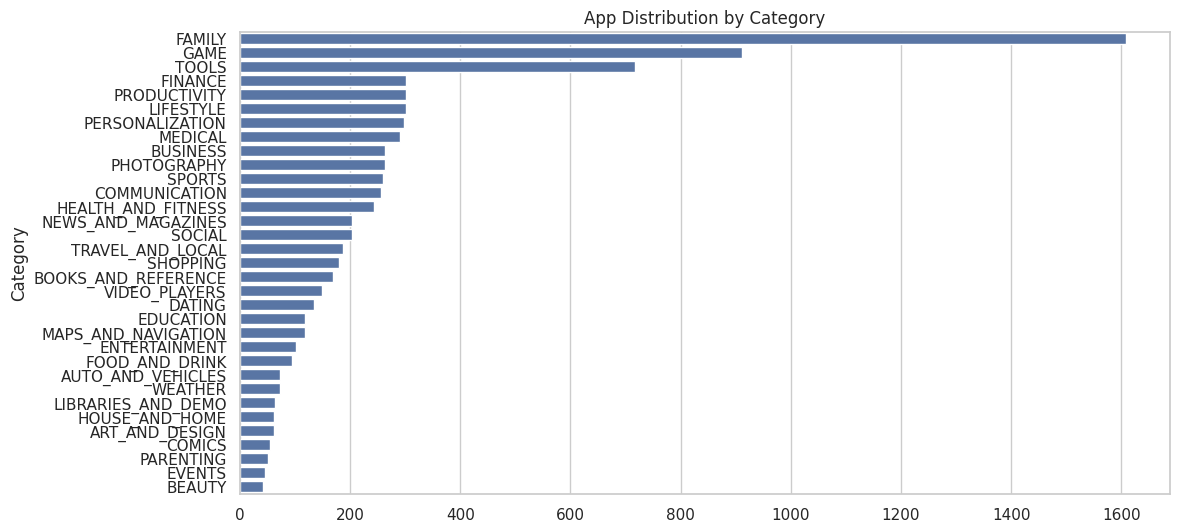

In [8]:
category_counts = apps['Category'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title("App Distribution by Category")
plt.show()

In [9]:
fig = px.bar(
    category_counts,
    x=category_counts.values,
    y=category_counts.index,
    orientation='h',
    title="Category Distribution"
)
fig.show()

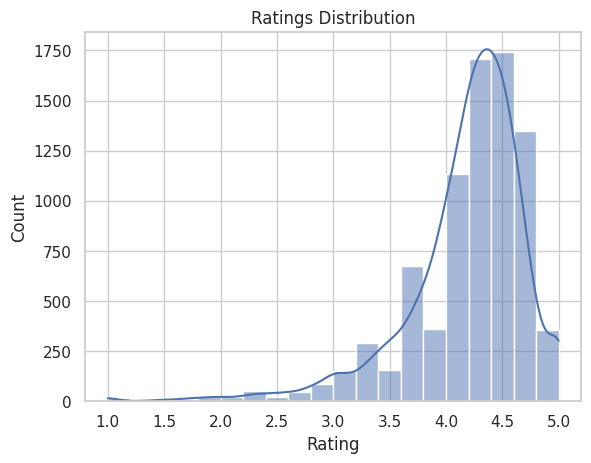

In [10]:
sns.histplot(apps['Rating'], bins=20, kde=True)
plt.title("Ratings Distribution")
plt.show()

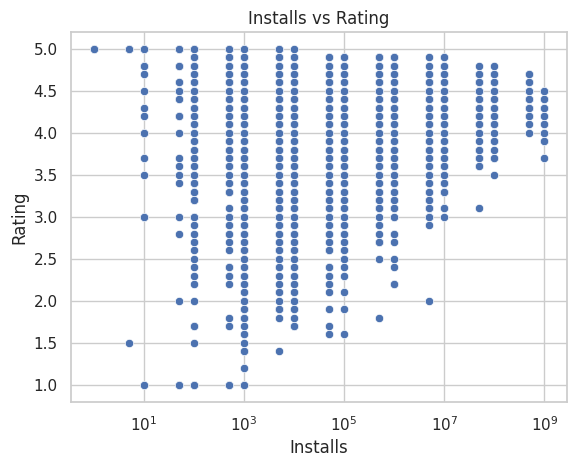

In [11]:
sns.scatterplot(x='Installs', y='Rating', data=apps)
plt.xscale('log')
plt.title("Installs vs Rating")
plt.show()

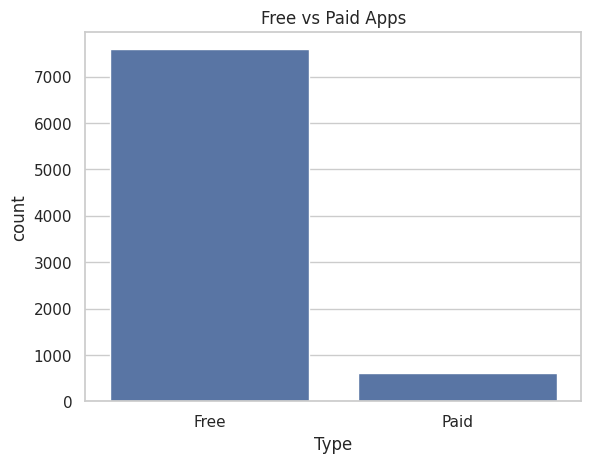

In [12]:
sns.countplot(x='Type', data=apps)
plt.title("Free vs Paid Apps")
plt.show()

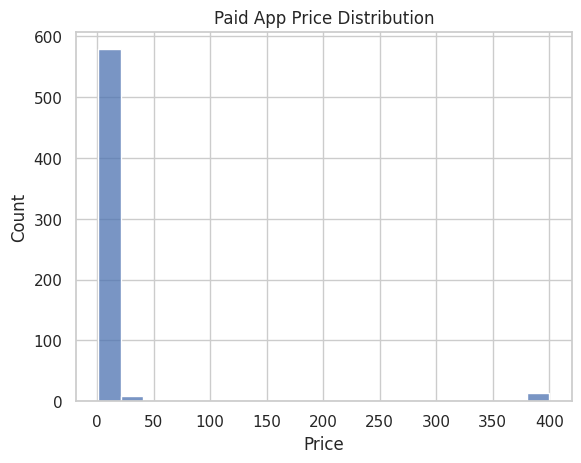

In [13]:
paid_apps = apps[apps['Type'] == 'Paid']

sns.histplot(paid_apps['Price'], bins=20)
plt.title("Paid App Price Distribution")
plt.show()

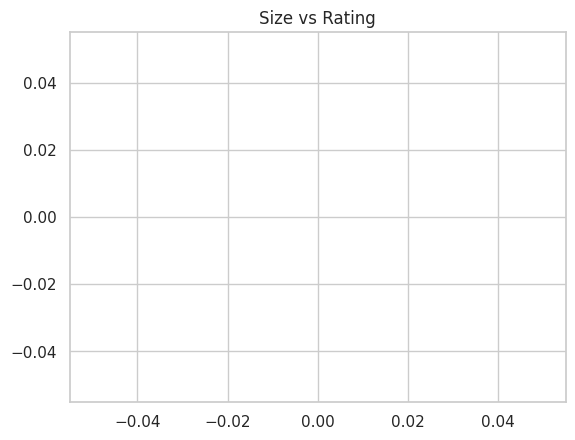

In [14]:
sns.scatterplot(x='Size', y='Rating', data=apps)
plt.title("Size vs Rating")
plt.show()

In [15]:
reviews.dropna(subset=['Translated_Review'], inplace=True)

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

reviews['Sentiment_Score'] = reviews['Translated_Review'].apply(get_sentiment)

def label_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Negative'

reviews['Sentiment'] = reviews['Sentiment_Score'].apply(label_sentiment)

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Score
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,1.00
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,0.25
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,0.40
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,1.00
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,1.00


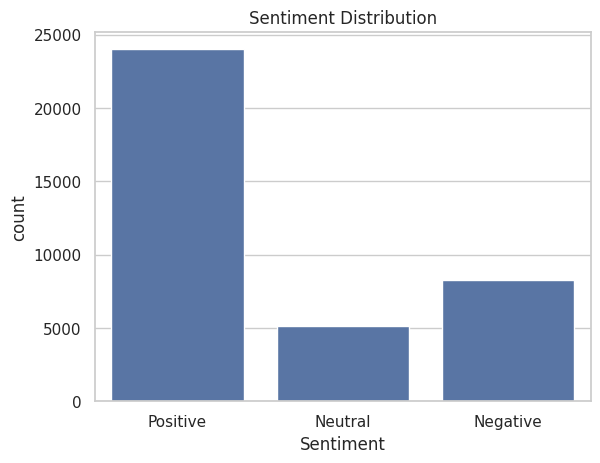

In [16]:
sns.countplot(x='Sentiment', data=reviews)
plt.title("Sentiment Distribution")
plt.show()

In [17]:
merged = pd.merge(apps, reviews, on='App', how='inner')

merged.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Score
0,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000,-0.250
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333,-0.725
2,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000,0.000
3,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000,0.500
4,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000,-0.800


In [18]:
merged = pd.merge(apps, reviews, on='App', how='inner')

merged.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Score
0,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000,-0.250
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333,-0.725
2,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000,0.000
3,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000,0.500
4,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000,-0.800


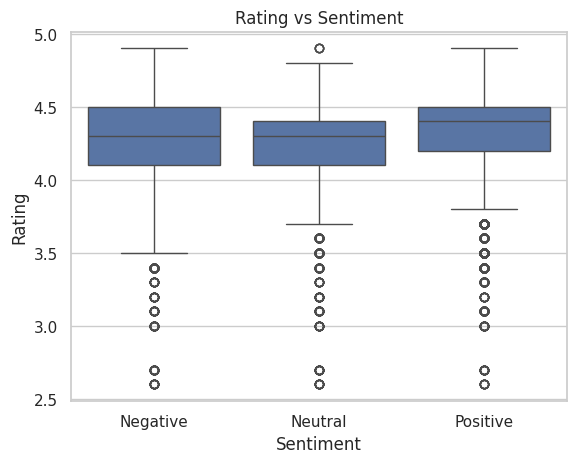

In [19]:
sns.boxplot(x='Sentiment', y='Rating', data=merged)
plt.title("Rating vs Sentiment")
plt.show()

In [20]:
cat_rating = apps.groupby('Category')['Rating'].mean().sort_values()

fig = px.bar(
    cat_rating,
    x=cat_rating.values,
    y=cat_rating.index,
    orientation='h',
    title="Average Rating by Category"
)
fig.show()

In [21]:
fig = px.histogram(apps, x='Installs', nbins=50, title="Installs Distribution")
fig.show()

In [22]:
print("📊 Top Category:", apps['Category'].value_counts().idxmax())
print("⭐ Highest Rated Category:", apps.groupby('Category')['Rating'].mean().idxmax())
print("💰 Most Expensive App:", apps['Price'].max())
print("📥 Max Installs:", apps['Installs'].max())

📊 Top Category: FAMILY
⭐ Highest Rated Category: EVENTS
💰 Most Expensive App: 400.0
📥 Max Installs: 1000000000
